<a href="https://colab.research.google.com/github/luciarc2004-sketch/TFG-Modelado-capas-iono-y-tropo/blob/main/bien.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The data is already loaded in the `data` variable. We can directly access the `vtec_assimilated_tecu` values within the `data['data']['grid']` dictionary.

The URL for the data is stored in the `url` variable. You can modify this variable to change the data source.

In [8]:
!pip install cartopy
import requests
import json

In [10]:
#https://impc.dlr.de/SWE/Total_Electron_Content/TEC_Near_Real-Time/DLR_GNSS_GCG_L4_VTEC-NTCM-SCM_NC_GLOBAL/v2.0.0/2025/295/03/DLR_GNSS_GCG_L4_VTEC-NTCM-SCM_NC_GLOBAL_2025-10-22T02-55-30_2025-10-22T03-00-00_295_D.json"
url="https://impc.dlr.de/SWE/Total_Electron_Content/TEC_Near_Real-Time/DLR_GNSS_GCG_L4_VTEC-NTCM-SCM_NC_GLOBAL/v2.0.0/latest/DLR_GNSS_GCG_L4_VTEC-NTCM-SCM_NC_GLOBAL_latest_D.json"

# Fetch data from the URL
try:
    response = requests.get(url)
    response.raise_for_status() # Raise an exception for HTTP errors
    data = response.json()
except requests.exceptions.RequestException as e:
    print(f"Error fetching data: {e}")
    data = {} # Initialize data as empty dict to avoid KeyError
except json.JSONDecodeError as e:
    print(f"Error decoding JSON: {e}")
    data = {} # Initialize data as empty dict to avoid KeyError

vtec_values_list = []
if 'data' in data and 'grid' in data['data']:
    grid_content = data['data']['grid']
    if 'features' in grid_content:
        for feature in grid_content['features']:
            if 'properties' in feature and 'vtec_assimilated_tecu' in feature['properties']:
                vtec_values_list.append(feature['properties']['vtec_assimilated_tecu'])
print((vtec_values_list))


[2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.682, 2.485, 2.587, 2.693, 2.802, 2.911, 3.016, 3.117, 3.211, 3.297, 3.373, 3.44, 3.498, 3.547, 3.589, 3.625, 3.656, 3.682, 3.705, 3.724, 3.741, 3.754, 3.764, 3.77, 3.77, 3.763, 3.748, 3.724, 3.69, 3.644, 3.586, 3.516, 3.434, 3.341, 3.238, 3.127, 3.009, 2.887, 2.763, 2.638, 2.514, 2.393, 2.277, 2.168, 2.066, 1.974, 1.892, 1.821, 1.763, 1.716, 1.682, 1.659, 1.647, 1.645, 1.651, 1.663, 1.681, 1.702, 1.726, 1.752, 1.778, 1.806, 1.835, 1.866, 1.9, 1.938, 1.98, 2.029, 2.085, 2.148, 2.22, 2.3, 2

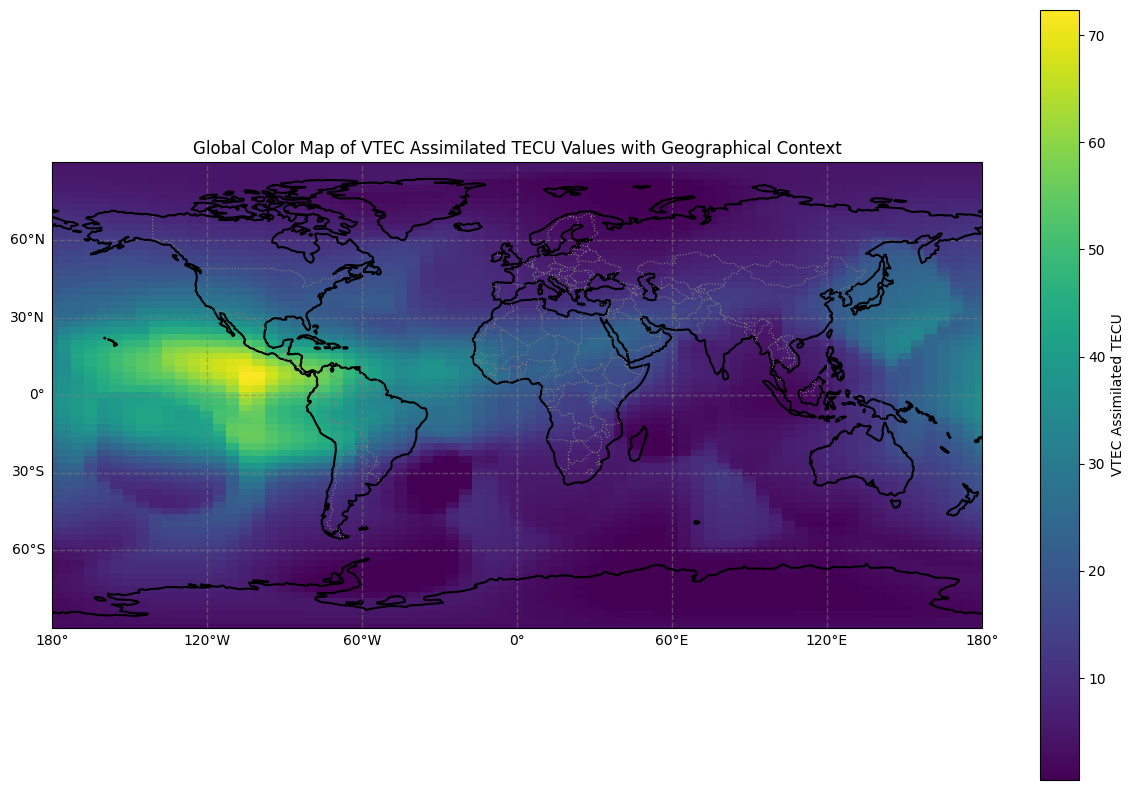

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define the number of columns per row and rows based on user input
num_cols_per_row = 73 # Longitude steps
num_rows = 73         # Latitude steps

# Create longitude and latitude arrays
# Longitude from -180 to +180, step 5 degrees
longitudes = np.arange(-180, 180 + 5, 5)
# Latitude from -90 to +90, step 2.5 degrees
latitudes = np.arange(-90, 90 + 2.5, 2.5)

# Check if the list length matches the expected grid size
expected_length = num_rows * num_cols_per_row
if len(vtec_values_list) != expected_length:
    print(f"Error: The length of vtec_values_list ({len(vtec_values_list)}) does not match the expected grid size of {expected_length} ({num_rows}x{num_cols_per_row}).")
else:
    # Reshape the 1D list into a 2D numpy array
    vtec_grid = np.array(vtec_values_list).reshape(num_rows, num_cols_per_row)

    # Create the figure and a GeoAxes for the map
    fig = plt.figure(figsize=(15, 10)) # Increased figure size for better map visualization
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) # Use PlateCarree projection

    # Set the extent of the map to cover the entire globe
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

    # Add features to the map with explicit zorder for visibility
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0) # Draw ocean first, lowest zorder
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', zorder=1) # Land above ocean

    # Plot the VTEC data as a pcolormesh (more suitable for grid data on maps)
    # The 'transform' argument tells cartopy that the data coordinates are in PlateCarree
    mesh = ax.pcolormesh(longitudes, latitudes, vtec_grid, cmap='viridis', transform=ccrs.PlateCarree(), shading='auto', zorder=2) # VTEC data on top of land/ocean

    ax.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black', zorder=3) # Coastline on top of VTEC data
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8, edgecolor='grey', zorder=3) # Borders on top

    # Add a colorbar
    plt.colorbar(mesh, ax=ax, label='VTEC Assimilated TECU', orientation='vertical', pad=0.05)

    # Add gridlines with labels
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabels_top = False
    gl.ylabels_right = False

    plt.title('Global Color Map of VTEC Assimilated TECU Values with Geographical Context')
    plt.xlabel('Longitude (°)')
    plt.ylabel('Latitude (°)')
    plt.show()

### Global Color Map of VTEC Assimilated TECU Values with Interpolation

This section generates a global color map of VTEC Assimilated TECU values, similar to the previous plot, but with added interpolation between the data points to create a smoother visualization. We will use `scipy.interpolate.griddata` for this purpose, interpolating the existing `vtec_grid` onto a finer grid.

In [14]:
from scipy.interpolate import griddata

# Create a finer grid for interpolation
# Adjust step sizes for a smoother interpolation
fine_longitudes = np.arange(-180, 180.1, 1) # 1-degree steps
fine_latitudes = np.arange(-90, 90.1, 0.5)   # 0.5-degree steps

# Create meshgrids for original and fine grids
lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)
fine_lon_grid, fine_lat_grid = np.meshgrid(fine_longitudes, fine_latitudes)

# Flatten the original coordinates and data for interpolation
points = np.array([lon_grid.flatten(), lat_grid.flatten()]).T
values = vtec_grid.flatten()

# Perform interpolation using 'linear' method
# Other methods like 'nearest' or 'cubic' can also be used depending on desired smoothness
interpolated_vtec_grid = griddata(points, values, (fine_lon_grid, fine_lat_grid), method='linear')

print("Interpolation complete. The interpolated data is stored in `interpolated_vtec_grid`")

Interpolation complete. The interpolated data is stored in `interpolated_vtec_grid`


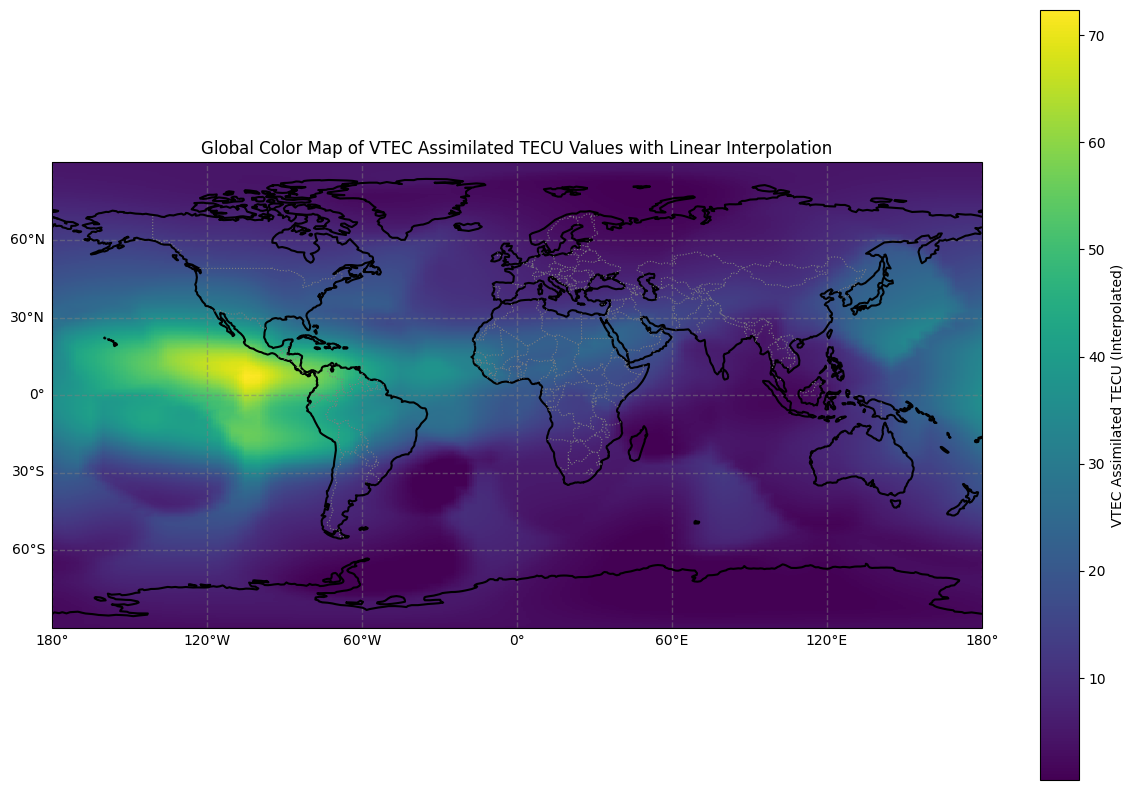

In [15]:
# Create the figure and a GeoAxes for the interpolated map
fig_interp = plt.figure(figsize=(15, 10))
ax_interp = fig_interp.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Set the extent of the map to cover the entire globe
ax_interp.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

# Add features to the map with explicit zorder for visibility
ax_interp.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
ax_interp.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', zorder=1)

# Plot the interpolated VTEC data as a pcolormesh
mesh_interp = ax_interp.pcolormesh(fine_longitudes, fine_latitudes, interpolated_vtec_grid,
                                   cmap='viridis', transform=ccrs.PlateCarree(), shading='auto', zorder=2)

ax_interp.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black', zorder=3)
ax_interp.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8, edgecolor='grey', zorder=3)

# Add a colorbar for the interpolated map
plt.colorbar(mesh_interp, ax=ax_interp, label='VTEC Assimilated TECU (Interpolated)', orientation='vertical', pad=0.05)

# Add gridlines with labels
gl_interp = ax_interp.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl_interp.top_labels = False
gl_interp.right_labels = False
gl_interp.xlabels_top = False
gl_interp.ylabels_right = False

plt.title('Global Color Map of VTEC Assimilated TECU Values with Linear Interpolation')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.show()

### Global Color Map of VTEC Assimilated TECU Values with Linear Interpolation (Zoomed to Europe)

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


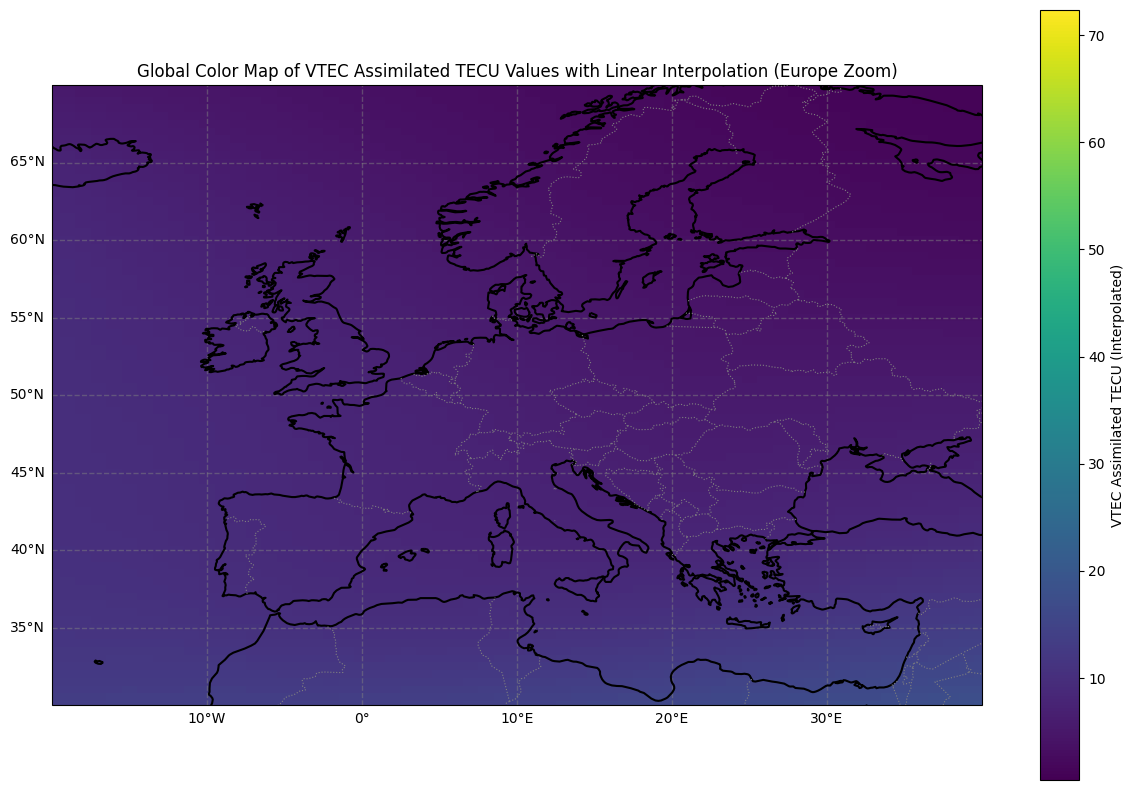

In [26]:
# Create the figure and a GeoAxes for the interpolated map, zoomed to Europe
fig_europe_interp = plt.figure(figsize=(15, 10))
ax_europe_interp = fig_europe_interp.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Set the extent of the map to cover Europe
# Adjust these values for your desired zoom level over Europe
ax_europe_interp.set_extent([-20, 40, 30, 70], crs=ccrs.PlateCarree()) # Example extent for Europe

# Add features to the map with explicit zorder for visibility
ax_europe_interp.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
ax_europe_interp.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', zorder=1)

# Plot the interpolated VTEC data as a pcolormesh
mesh_europe_interp = ax_europe_interp.pcolormesh(fine_longitudes, fine_latitudes, interpolated_vtec_grid,
                                   cmap='viridis', transform=ccrs.PlateCarree(), shading='auto', zorder=2)

ax_europe_interp.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black', zorder=3)
ax_europe_interp.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8, edgecolor='grey', zorder=3)

# Add a colorbar for the interpolated map
plt.colorbar(mesh_europe_interp, ax=ax_europe_interp, label='VTEC Assimilated TECU (Interpolated)', orientation='vertical', pad=0.05)

# Add gridlines with labels
gl_europe_interp = ax_europe_interp.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl_europe_interp.top_labels = False
gl_europe_interp.right_labels = False
gl_europe_interp.xlabels_top = False
gl_europe_interp.ylabels_right = False

plt.title('Global Color Map of VTEC Assimilated TECU Values with Linear Interpolation (Europe Zoom)')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.show()

### Interactive Map with Region Selection Widget

This section introduces an interactive widget using `ipywidgets` to allow you to select different geographical regions (like Europe, North America, etc.) and dynamically update the interpolated VTEC map. This provides a more flexible way to explore the data.

First, we define a set of predefined regions with their corresponding geographical extents.

In [29]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define predefined regions with their extents (min_lon, max_lon, min_lat, max_lat)
predefined_regions = {
    'Global': [-180, 180, -90, 90],
    'Europa': [-20, 40, 30, 70],
    'Norteamérica': [-170, -50, 10, 80],
    'Sudamérica': [-90, -30, -60, 20],
    'África': [-20, 50, -40, 40],
    'Asia': [30, 180, -10, 80],
    'Oceanía': [100, 180, -50, 0]
}

# Create a dropdown widget for region selection
region_selector = widgets.Dropdown(
    options=list(predefined_regions.keys()),
    value='Global',
    description='Seleccionar Región:',
    disabled=False,
)

# Create an output widget to display the map
output_map = widgets.Output()

def plot_interactive_map(region_name):
    with output_map:
        clear_output(wait=True)
        min_lon, max_lon, min_lat, max_lat = predefined_regions[region_name]

        fig_interact = plt.figure(figsize=(15, 10))
        ax_interact = fig_interact.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

        ax_interact.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

        ax_interact.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
        ax_interact.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', zorder=1)

        mesh_interact = ax_interact.pcolormesh(fine_longitudes, fine_latitudes, interpolated_vtec_grid,
                                           cmap='viridis', transform=ccrs.PlateCarree(), shading='auto', zorder=2)

        ax_interact.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black', zorder=3)
        ax_interact.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8, edgecolor='grey', zorder=3)

        plt.colorbar(mesh_interact, ax=ax_interact, label='VTEC Assimilated TECU (Interpolated)', orientation='vertical', pad=0.05)

        gl_interact = ax_interact.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
        gl_interact.top_labels = False
        gl_interact.right_labels = False
        gl_interact.xlabels_top = False
        gl_interact.ylabels_right = False

        plt.title(f'VTEC Assimilated TECU con Interpolación ({region_name} Zoom)')
        plt.xlabel('Longitud (°)')
        plt.ylabel('Latitud (°)')
        plt.show()

# Link the dropdown to the plotting function
widgets.interactive_output(plot_interactive_map, {'region_name': region_selector})

# Display the widget and the output area
display(region_selector, output_map)

Dropdown(description='Seleccionar Región:', options=('Global', 'Europa', 'Norteamérica', 'Sudamérica', 'África…

Output()

In [ ]:
!pip install geopy

In [18]:
from geopy.geocoders import Nominatim
import numpy as np

def get_city_coordinates(city_name):
    """Fetches the latitude and longitude for a given city name."""
    geolocator = Nominatim(user_agent="vtec_app") # Provide a user_agent
    try:
        location = geolocator.geocode(city_name)
        if location:
            print(f"Coordinates for {city_name}: Latitude {location.latitude}, Longitude {location.longitude}")
            return location.latitude, location.longitude
        else:
            print(f"Could not find coordinates for {city_name}.")
            return None, None
    except Exception as e:
        print(f"Error fetching coordinates for {city_name}: {e}")
        return None, None

def get_interpolated_vtec_at_coordinates(lat, lon, fine_latitudes, fine_longitudes, interpolated_vtec_grid):
    """Finds the interpolated VTEC value at the closest grid point to the given coordinates."""
    if lat is None or lon is None:
        return None

    # Find the nearest latitude and longitude in the fine grid
    lat_idx = np.argmin(np.abs(fine_latitudes - lat))
    lon_idx = np.argmin(np.abs(fine_longitudes - lon))

    # Get the VTEC value from the interpolated grid
    vtec_value = interpolated_vtec_grid[lat_idx, lon_idx]

    print(f"Nearest grid point: Latitude {fine_latitudes[lat_idx]}, Longitude {fine_longitudes[lon_idx]}")
    return vtec_value

# --- Demo of usage ---
# Get city name input from the user
city_name = input("Valor VTEC de ciudad: ")

# Get coordinates for the city
city_lat, city_lon = get_city_coordinates(city_name)

if city_lat is not None and city_lon is not None:
    # Get the interpolated VTEC value
    vtec_at_city = get_interpolated_vtec_at_coordinates(city_lat, city_lon, fine_latitudes, fine_longitudes, interpolated_vtec_grid)
    if vtec_at_city is not None:
        print(f"The interpolated VTEC value for {city_name} is: {vtec_at_city:.3f} TECU")
    else:
        print(f"Could not retrieve VTEC value for {city_name}.")
else:
    print("Cannot proceed without valid city coordinates.")

Valor VTEC de ciudad: seul
Coordinates for seul: Latitude 37.5666791, Longitude 126.9782914
Nearest grid point: Latitude 37.5, Longitude 127.0
The interpolated VTEC value for seul is: 21.231 TECU


Enter the constellation name (GPS, Galileo, GLONASS, BeiDou): GLONASS
Using frequency f = 1602 MHz for GLONASS.


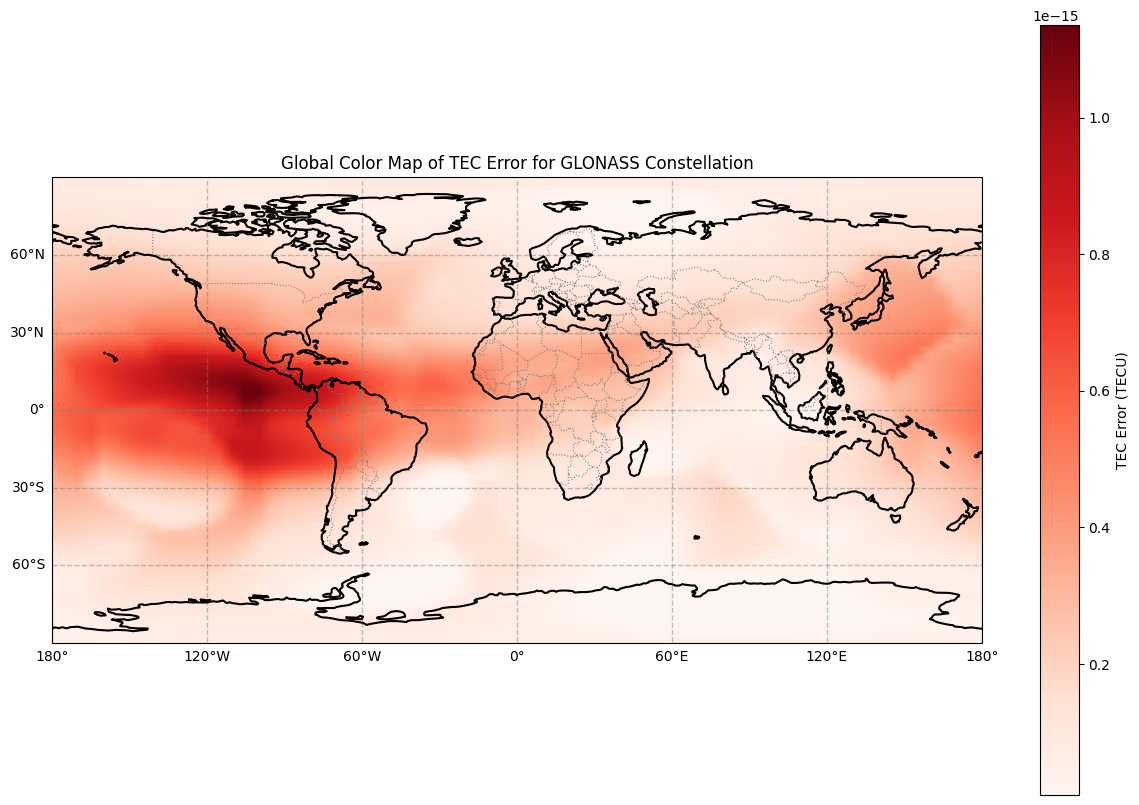

In [23]:
# Map constellation names to their respective frequencies
constellation_frequencies = {
    "GPS": 1575.42,
    "Galileo": 1575.42,
    "GLONASS": 1602,
    "BeiDou": 1561.10
}

# Get constellation name from user
constellation_name = input("Enter the constellation name (GPS, Galileo, GLONASS, BeiDou): ").strip().upper()

# Get the frequency for the chosen constellation
f = constellation_frequencies.get(constellation_name)

if f is None:
    print(f"Error: Invalid constellation name '{constellation_name}'. Please choose from GPS, Galileo, GLONASS, or BeiDou.")
else:
    print(f"Using frequency f = {f} MHz for {constellation_name}.")

    # Calculate the TEC error grid
    # The formula is 40.3 * tec / f^2. Here 'tec' is our interpolated_vtec_grid.
    # f needs to be converted from MHz to Hz for the formula (f * 1e6)
    tec_error_grid = (40.3 * interpolated_vtec_grid) / ( (f * 1e6)**2 )

    # Calculate the VTEC grid with error (assuming this is how 'calculated' is meant)
    # The user requested 'diferencia entre el valor VTEC real y el calculado tras aplicar el error'
    # Let's interpret 'calculated' as 'interpolated_vtec_grid + tec_error_grid'
    # And the difference as 'calculated - real' which is simply 'tec_error_grid'

    # The request is to visualize the *difference* between real and calculated after applying the error.
    # If 'calculated' means 'interpolated_vtec_grid + error', then the difference to visualize is simply the 'error' itself.
    # Let's plot the tec_error_grid directly as it represents the difference based on the formula.

    # Create the figure and a GeoAxes for the TEC Error map
    fig_error = plt.figure(figsize=(15, 10))
    ax_error = fig_error.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Set the extent of the map to cover the entire globe
    ax_error.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

    # Add features to the map with explicit zorder for visibility
    ax_error.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
    ax_error.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', zorder=1)

    # Plot the TEC Error data as a pcolormesh
    mesh_error = ax_error.pcolormesh(fine_longitudes, fine_latitudes, tec_error_grid,
                                     cmap='Reds', transform=ccrs.PlateCarree(), shading='auto', zorder=2)

    ax_error.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black', zorder=3)
    ax_error.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8, edgecolor='grey', zorder=3)

    # Add a colorbar for the TEC Error map
    plt.colorbar(mesh_error, ax=ax_error, label='TEC Error (TECU)', orientation='vertical', pad=0.05)

    # Add gridlines with labels
    gl_error = ax_error.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
    gl_error.top_labels = False
    gl_error.right_labels = False
    gl_error.xlabels_top = False
    gl_error.ylabels_right = False

    plt.title(f'Global Color Map of TEC Error for {constellation_name} Constellation')
    plt.xlabel('Longitude (°)')
    plt.ylabel('Latitude (°)')
    plt.show()

### Calculated `40.3 / f^2` Values for Each Constellation

Below is a table showing the calculated `40.3 / f^2` value for each supported GNSS constellation. Note that `f` is in Hz for this calculation, so the MHz values from `constellation_frequencies` are multiplied by `1e6`.

In [25]:
import pandas as pd
import numpy as np

# Map constellation names to their respective frequencies
constellation_frequencies = {
    "GPS": 1575.42,
    "Galileo": 1575.42,
    "GLONASS": 1602,
    "BeiDou": 1561.10
}

# Create lists to store data for the table
constellation_names_list = []
calculated_values_list = []
frequency_mhz_list = []

for name, freq_mhz in constellation_frequencies.items():
    freq_hz = freq_mhz * 1e6 # Convert MHz to Hz
    calculated_value = 40.3 / (freq_hz**2)
    constellation_names_list.append(name)
    calculated_values_list.append(calculated_value)
    frequency_mhz_list.append(freq_mhz)

# Create a Pandas DataFrame
df_constellation_values = pd.DataFrame({
    'Constellation': constellation_names_list,
    'Frequency (MHz)': frequency_mhz_list,
    '40.3 / f^2 (m^3/TECU)': calculated_values_list
})

# Calculate the maximum and minimum '40.3 / f^2' values
max_calculated_value = df_constellation_values['40.3 / f^2 (m^3/TECU)'].max()
min_calculated_value = df_constellation_values['40.3 / f^2 (m^3/TECU)'].min()

# Add the new columns for ratios
df_constellation_values['Ratio to Max (40.3 / f^2)'] = df_constellation_values['40.3 / f^2 (m^3/TECU)'] / max_calculated_value
df_constellation_values['Ratio to Min (40.3 / f^2)'] = df_constellation_values['40.3 / f^2 (m^3/TECU)'] / min_calculated_value

# Display the DataFrame
display(df_constellation_values)

,Constellation,Frequency (MHz),40.3 / f^2 (m^3/TECU),Ratio to Max (40.3 / f^2),Ratio to Min (40.3 / f^2)
0,GPS,1575.42,1.623724e-17,0.981903,1.034028
1,Galileo,1575.42,1.623724e-17,0.981903,1.034028
2,GLONASS,1602.00,1.570291e-17,0.949591,1.000000
3,BeiDou,1561.10,1.653650e-17,1.000000,1.053085
